# Data Generation

In [1]:
import deepmimo as dm
import numpy as np
import matplotlib.pyplot as plt

print("DeepMIMO version:", dm.__version__)
print("NumPy version:", np.__version__)
print("Setup verified ✓")

Install with: pip install 'deepmimo[aodt]'
DeepMIMO version: 4.0.0
NumPy version: 2.2.6
Setup verified ✓


In [23]:
dm.download('O1_60')

Scenario "o1_60" already exists in /Users/aarushagarwal/Desktop/thz_beamforming/notebooks/deepmimo_scenarios


In [24]:
channels = dataset.compute_channels()

# Explore the structure
print("Number of base stations:", len(channels))
print("\nFor each base station:")
for i, ch in enumerate(channels):
    ch_arr = np.array(ch)
    print(f"  BS {i}: shape {ch_arr.shape}")

Generating channels: 100%|██████████| 487711/487711 [00:13<00:00, 37160.56it/s]


Number of base stations: 54

For each base station:
  BS 0: shape (497931, 1, 8, 1)
  BS 1: shape (199281, 1, 8, 1)
  BS 2: shape (487711, 1, 8, 1)
  BS 3: shape (497931, 1, 8, 1)
  BS 4: shape (199281, 1, 8, 1)
  BS 5: shape (487711, 1, 8, 1)
  BS 6: shape (497931, 1, 8, 1)
  BS 7: shape (199281, 1, 8, 1)
  BS 8: shape (487711, 1, 8, 1)
  BS 9: shape (497931, 1, 8, 1)
  BS 10: shape (199281, 1, 8, 1)
  BS 11: shape (487711, 1, 8, 1)
  BS 12: shape (497931, 1, 8, 1)
  BS 13: shape (199281, 1, 8, 1)
  BS 14: shape (487711, 1, 8, 1)
  BS 15: shape (497931, 1, 8, 1)
  BS 16: shape (199281, 1, 8, 1)
  BS 17: shape (487711, 1, 8, 1)
  BS 18: shape (497931, 1, 8, 1)
  BS 19: shape (199281, 1, 8, 1)
  BS 20: shape (487711, 1, 8, 1)
  BS 21: shape (497931, 1, 8, 1)
  BS 22: shape (199281, 1, 8, 1)
  BS 23: shape (487711, 1, 8, 1)
  BS 24: shape (497931, 1, 8, 1)
  BS 25: shape (199281, 1, 8, 1)
  BS 26: shape (487711, 1, 8, 1)
  BS 27: shape (497931, 1, 8, 1)
  BS 28: shape (199281, 1, 8, 1)
 

In [25]:
import deepmimo as dm
import numpy as np
import matplotlib.pyplot as plt

# Load the full dataset
dataset = dm.load('o1_60')

# Extract just the first base station (index 0)
# MacroDataset contains multiple TX/RX pairs - get the first one
bs0 = dataset[0]

# Now inspect this single BS dataset
print("Type:", type(bs0))
print("Keys available:", list(bs0.keys()) if hasattr(bs0, 'keys') else dir(bs0))

Loading TXRX PAIR: TXset 10 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 10 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 10 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 11 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 11 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 11 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 12 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 12 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 12 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 13 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 13 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 13 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TXRX PAIR: TXset 14 (tx_idx 0) & RXset 0 (rx_idxs 497931)
Loading TXRX PAIR: TXset 14 (tx_idx 0) & RXset 1 (rx_idxs 199281)
Loading TXRX PAIR: TXset 14 (tx_idx 0) & RXset 2 (rx_idxs 487711)
Loading TX

In [26]:
# Get positions from the first BS dataset
positions = bs0['rx_pos']
print("Type:", type(positions))
print("Shape:", positions.shape)
print("\nFirst 5 positions:")
print(positions[:5])
print("\nX range:", positions[:,0].min(), "to", positions[:,0].max())
print("Y range:", positions[:,1].min(), "to", positions[:,1].max())
print("Z range:", positions[:,2].min(), "to", positions[:,2].max())

Type: <class 'numpy.ndarray'>
Shape: (497931, 3)

First 5 positions:
[[242.423 297.171   2.   ]
 [242.623 297.171   2.   ]
 [242.823 297.171   2.   ]
 [243.023 297.171   2.   ]
 [243.223 297.171   2.   ]]

X range: 242.423 to 278.423
Y range: 297.171 to 847.171
Z range: 2.0 to 2.0


In [27]:
#This is the full picture:
#497,931 users on a grid spanning X: 242 to 278m, Y: 297 to 847m
#All at Z=2m (ground level, as expected)
#Users are spaced 0.2m apart (242.423, 242.623, 242.823...)
#The grid is roughly 36m wide × 550m long — a long outdoor street corridor, perfect for trajectories

# The grid is 36m wide (X) and 550m long (Y)
# Users spaced 0.2m apart
# We'll define 3 trajectories as sequences of (x,y) waypoints
# then find the nearest user index for each waypoint

def find_nearest_user(positions, x, y):
    """Find the index of the user closest to (x, y)"""
    dists = np.sqrt((positions[:,0] - x)**2 + (positions[:,1] - y)**2)
    return np.argmin(dists)

# Number of timesteps per trajectory
#T = 50
T = 200

# --- Trajectory 1: Straight Line ---
# Walk straight down the middle of the corridor (constant X, increasing Y)
x_mid = 260.0  # middle of X range (242 to 278)
straight_waypoints = [(x_mid, y) for y in np.linspace(300, 600, T)]

# --- Trajectory 2: Gentle Curve ---
# Walk down the corridor with a slow S-curve in X
curve_waypoints = [
    (260.0 + 8 * np.sin(2 * np.pi * i / T), 300 + 300 * i / T)
    for i in range(T)
]

# --- Trajectory 3: Sharp Turn ---
# Walk straight down Y, then abruptly turn and walk across X
half = T // 2
turn_waypoints = (
    [(260.0, 300 + 200 * i / half) for i in range(half)] +   # straight down
    [(260.0 + 18 * i / half, 500) for i in range(half)]       # sharp right turn
)

# Convert waypoints to user indices
straight_indices = [find_nearest_user(positions, x, y) for x, y in straight_waypoints]
curve_indices    = [find_nearest_user(positions, x, y) for x, y in curve_waypoints]
turn_indices     = [find_nearest_user(positions, x, y) for x, y in turn_waypoints]

# Verify by checking actual positions retrieved
straight_pos = positions[straight_indices]
curve_pos    = positions[curve_indices]
turn_pos     = positions[turn_indices]

print("Straight - first 3 positions:", straight_pos[:3])
print("Curve    - first 3 positions:", curve_pos[:3])
print("Turn     - first 3 positions:", turn_pos[:3])
print("\nAll indices look good ✓")

Straight - first 3 positions: [[260.023 299.971   2.   ]
 [260.023 301.571   2.   ]
 [260.023 302.971   2.   ]]
Curve    - first 3 positions: [[260.023 299.971   2.   ]
 [260.223 301.571   2.   ]
 [260.423 302.971   2.   ]]
Turn     - first 3 positions: [[260.023 299.971   2.   ]
 [260.023 301.971   2.   ]
 [260.023 303.971   2.   ]]

All indices look good ✓


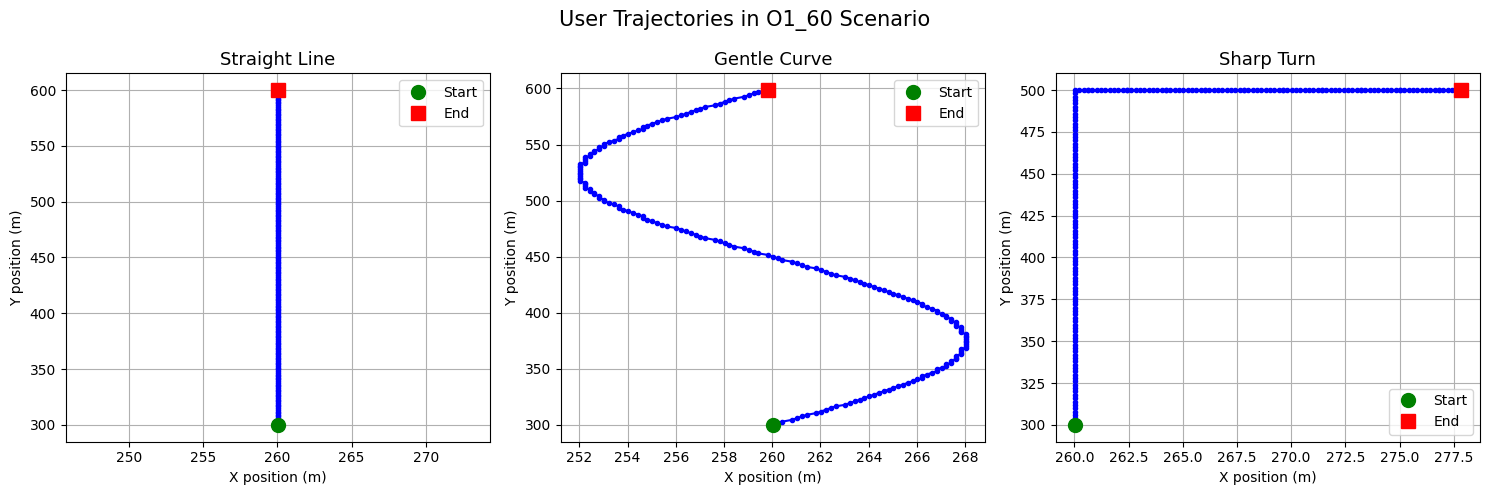

Trajectory plot saved ✓


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pos, title in zip(axes,
                           [straight_pos, curve_pos, turn_pos],
                           ['Straight Line', 'Gentle Curve', 'Sharp Turn']):
    ax.plot(pos[:, 0], pos[:, 1], 'b.-', markersize=6)
    ax.plot(pos[0, 0], pos[0, 1], 'go', markersize=10, label='Start')
    ax.plot(pos[-1, 0], pos[-1, 1], 'rs', markersize=10, label='End')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('X position (m)')
    ax.set_ylabel('Y position (m)')
    ax.legend()
    ax.grid(True)

plt.suptitle('User Trajectories in O1_60 Scenario', fontsize=15)
plt.tight_layout()
plt.savefig('../results/trajectories_visualization.png', dpi=150)
plt.show()
print("Trajectory plot saved ✓")

In [29]:
# Combine all indices we need - only 150 users total
all_indices = list(set(straight_indices + curve_indices + turn_indices))
print(f"Total unique users needed: {len(all_indices)} (out of 497,931)")

# Trim the dataset to only these users - much faster than computing all
bs0_trimmed = bs0.trim(idxs=all_indices)
print("Trimmed dataset ready ✓")

# Compute channels only for these users
print("Computing channels for trajectory users only...")
channels_small = bs0_trimmed.compute_channels()
channels_small = np.array(channels_small)
print("Channels shape:", channels_small.shape)

Total unique users needed: 575 (out of 497,931)
Trimmed dataset ready ✓
Computing channels for trajectory users only...


Generating channels: 100%|██████████| 575/575 [00:00<00:00, 13438.94it/s]

Channels shape: (575, 1, 8, 1)


In [30]:
# Build a lookup dictionary: original_user_index -> channel matrix
index_to_channel = {}
for lookup_pos, orig_idx in enumerate(all_indices):
    index_to_channel[orig_idx] = channels_small[lookup_pos]

print(f"Channel lookup built for {len(index_to_channel)} users ✓")
print("Sample channel shape:", channels_small[0].shape)

Channel lookup built for 575 users ✓
Sample channel shape: (1, 8, 1)


In [31]:
# Extract positions and channels for each trajectory
def build_trajectory(positions, indices, index_to_channel):
    pos_seq = positions[indices]           # shape (T, 3)
    H_seq   = np.array([index_to_channel[i] for i in indices])  # shape (T, n_rx, n_tx, n_sub)
    return pos_seq, H_seq

pos_straight, H_straight = build_trajectory(positions, straight_indices, index_to_channel)
pos_curve,    H_curve    = build_trajectory(positions, curve_indices,    index_to_channel)
pos_turn,     H_turn     = build_trajectory(positions, turn_indices,     index_to_channel)

print("Straight — pos:", pos_straight.shape, "| H:", H_straight.shape)
print("Curve    — pos:", pos_curve.shape,    "| H:", H_curve.shape)
print("Turn     — pos:", pos_turn.shape,     "| H:", H_turn.shape)

Straight — pos: (200, 3) | H: (200, 1, 8, 1)
Curve    — pos: (200, 3) | H: (200, 1, 8, 1)
Turn     — pos: (200, 3) | H: (200, 1, 8, 1)


In [33]:
import os
os.makedirs('../data', exist_ok=True)

np.save('../data/trajectory_straight.npy',
        {'positions': pos_straight, 'channels': H_straight},
        allow_pickle=True)

np.save('../data/trajectory_curve.npy',
        {'positions': pos_curve, 'channels': H_curve},
        allow_pickle=True)

np.save('../data/trajectory_turn.npy',
        {'positions': pos_turn, 'channels': H_turn},
        allow_pickle=True)

# Verify by reloading one
test = np.load('../data/trajectory_straight.npy', allow_pickle=True).item()
print("Verification:")
print("  Positions shape:", test['positions'].shape)
print("  Channels shape: ", test['channels'].shape)

Verification:
  Positions shape: (200, 3)
  Channels shape:  (200, 1, 8, 1)
